# Homework 0 - Question 1: Practical Implementation of Low-Rank Image Approximation

**Full Name:** Farzan Rahmani

**Student ID:** 403210725

---
In this notebook, we will implement and analyze the concept of Low-Rank Approximation using Singular Value Decomposition (SVD) on an image for various ranks.

---
# Part(E): Image Reconstruction Using SVD

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from numpy.linalg import svd, norm

### 1. Loading Libraries and Sample Image

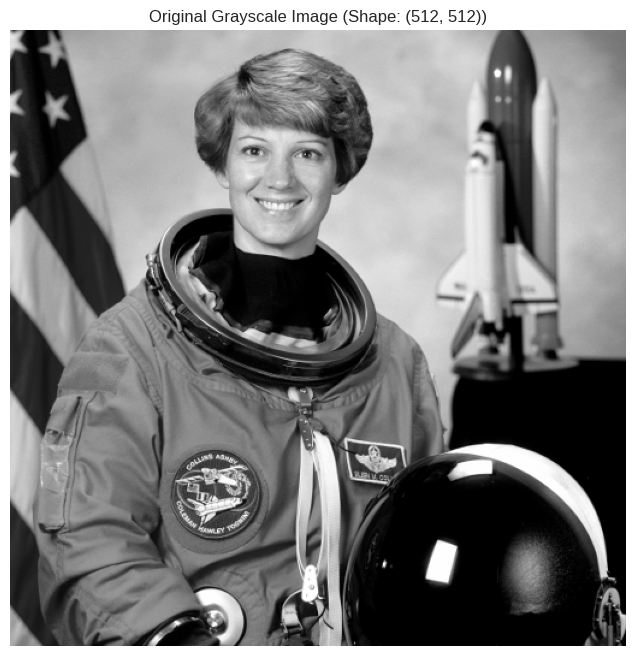

Dimensions of the image matrix A: (512, 512)


In [11]:
# Plotting style settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 8)

# Load a color image
image_color = data.astronaut()

# Convert to grayscale
A = color.rgb2gray(image_color)

# Display the image and its dimensions
plt.imshow(A, cmap='gray')
plt.title(f'Original Grayscale Image (Shape: {A.shape})')
plt.axis('off')
plt.show()

print(f"Dimensions of the image matrix A: {A.shape}")

### 2. Computing the Singular Value Decomposition (SVD)
In this section, you need to decompose the image matrix `A` into its SVD components: `U`, `s`, and `VT`.

In [12]:
# Description: Use the 'svd' function to compute the Singular Value Decomposition of the matrix 'A'.

# TODO: Perform SVD on the matrix 'A'.
# U, s, VT = None, None, None
U, s, VT = svd(A, full_matrices=True)

print(f"Shape of U: {U.shape}")
print(f"Number of singular values: {s.shape[0]}")
print(f"Shape of VT: {VT.shape}")

Shape of U: (512, 512)
Number of singular values: 512
Shape of VT: (512, 512)


### 3. Image Reconstruction and Error Calculation for Different Ranks (k)
Now, we will reconstruct the image and calculate the approximation error for a list of different ranks: `k_values`. This will help us understand the trade-off between compression and image quality.

In [16]:
k_values = [5, 15, 30, 50, 100]
reconstructed_images = []

for k in k_values:
    print(f'--- Analyzing for k = {k} ---')

    # Description: To build the approximated matrix A_k, you need to select the first k columns of U,
    # the first k singular values, and the first k rows of VT.

    # TODO: Reconstruct the image matrix A_k using the top k SVD components.
    # A_k = None
    A_k = U[:, :k] @ np.diag(s[:k]) @ VT[:k, :]
    # A_k = U[:, :k] @ (s[:k, np.newaxis] * VT[:k, :]) # can use this formula too (More efficient than creating a full diagonal matrix with np.diag(s[:k]))
    reconstructed_images.append(A_k)

    # TODO: Calculate the practical error (||A - A_k||_2).
    # practical_error = None
    practical_error = norm(A - A_k, ord=2) # spectral norm

    # TODO: Extract the theoretical error (sigma_{k+1}). Remember 0-based indexing.
    # theoretical_error = None
    theoretical_error = s[k] if k < len(s) else 0

    print(f"Practical Error (||A - A_k||_2): {practical_error}")
    print(f"Theoretical Error (sigma_{k+1}): {theoretical_error}")
    print(f"Diff between Practical and Theoretical Error: {abs(theoretical_error - practical_error)}\n")

--- Analyzing for k = 5 ---
Practical Error (||A - A_k||_2): 29.989251861984112
Theoretical Error (sigma_6): 29.98925186198411
Diff between Practical and Theoretical Error: 3.552713678800501e-15

--- Analyzing for k = 15 ---
Practical Error (||A - A_k||_2): 11.453026420355307
Theoretical Error (sigma_16): 11.453026420355314
Diff between Practical and Theoretical Error: 7.105427357601002e-15

--- Analyzing for k = 30 ---
Practical Error (||A - A_k||_2): 6.188232950337846
Theoretical Error (sigma_31): 6.188232950337844
Diff between Practical and Theoretical Error: 1.7763568394002505e-15

--- Analyzing for k = 50 ---
Practical Error (||A - A_k||_2): 3.8792530366929947
Theoretical Error (sigma_51): 3.8792530366929983
Diff between Practical and Theoretical Error: 3.552713678800501e-15

--- Analyzing for k = 100 ---
Practical Error (||A - A_k||_2): 1.7089599171771117
Theoretical Error (sigma_101): 1.7089599171771115
Diff between Practical and Theoretical Error: 2.220446049250313e-16



### 4. Visual Comparison of Reconstructed Images
Let's display the original image and all the reconstructed images side-by-side to visually assess the quality.

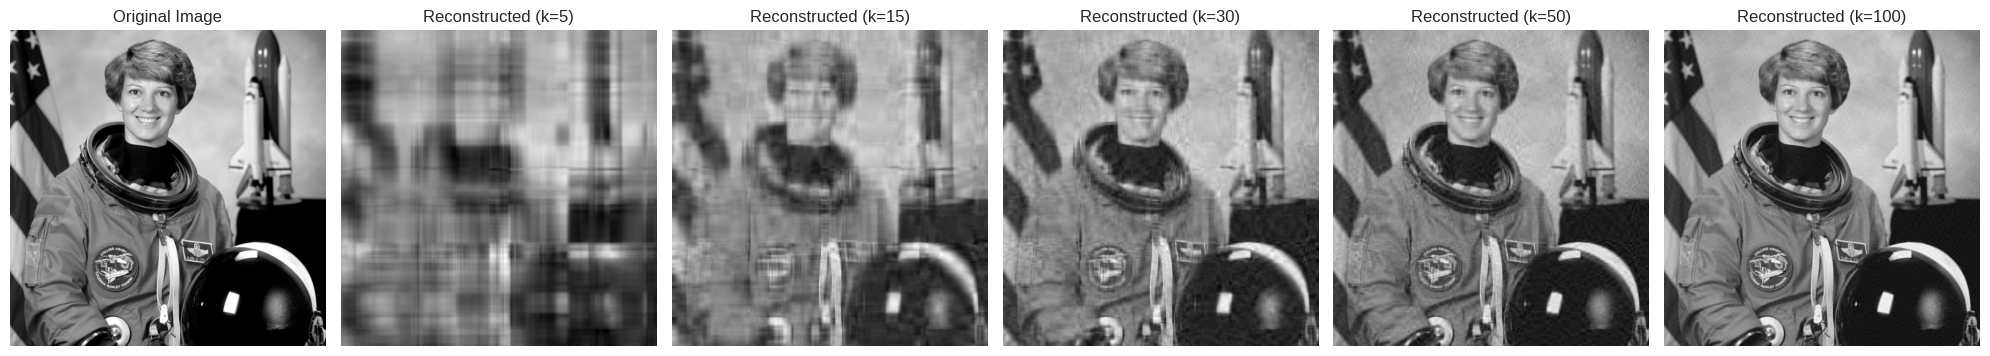

In [17]:
# Display the results
n_images = len(k_values)
fig, axes = plt.subplots(1, n_images + 1, figsize=(20, 5))

# Plot Original
axes[0].imshow(A, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Plot Reconstructed Images
for i, (k, recon_img) in enumerate(zip(k_values, reconstructed_images)):
    axes[i+1].imshow(recon_img, cmap='gray')
    axes[i+1].set_title(f'Reconstructed (k={k})')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

### 5. Final Analysis
**TODO:** Analyze the results you obtained.
1. Explain how the image quality changes as `k` increases.
2. Discuss the relationship between the practical and theoretical errors for each `k`.
3. Describe the trade-off between image compression (related to the value of `k`) and visual quality.

### Analysis of Low-Rank Image Approximation Results

#### 1. Explain how the image quality changes as `k` increases. (Image Quality vs. Rank (k))

As k increases, the image quality improves progressively, as clearly demonstrated in the reconstruction sequence:

- **k=5**: The image is severely degraded with only the coarsest features visible. The astronaut's face is barely recognizable, appearing as blurred blocks. Vertical and horizontal banding artifacts dominate, indicating that only the most dominant directional patterns are captured.

- **k=15**: Basic structural elements emerge. The astronaut's face becomes somewhat recognizable, and the helmet's general shape is visible. However, fine details like facial features, text on patches, and texture details remain heavily blurred.

- **k=30**: A significant quality improvement occurs. The astronaut's facial features are now clearly visible, including eyes, smile, and hair. The NASA patch and American flag become distinguishable. This represents a perceptually acceptable reconstruction for many applications.

- **k=50**: The image quality is quite good, with most details preserved. Facial features are sharp, text on patches is readable, and subtle textures in the spacesuit are visible. The reconstruction closely approximates the original.

- **k=100**: Nearly indistinguishable from the original image. All fine details, textures, and subtle gradations are faithfully reproduced. The human eye would struggle to detect differences without careful comparison.

**Key Insight**: Each additional singular value component captures progressively finer details. The first few singular values encode the dominant large-scale structures (low-frequency content), while higher-order components encode fine details and textures (high-frequency content). This hierarchical representation is what makes SVD so powerful for image compression.

#### 2. Discuss the relationship between the practical and theoretical errors for each `k`. (Practical vs. Theoretical Error Analysis)

The error measurements demonstrate remarkable agreement between theory and practice:

| k   | Practical Error (‖A - A_k‖₂) | Theoretical Error (σ_{k+1}) | Difference        |
|-----|------------------------------|------------------------------|-------------------|
| 5   | 29.989251861984112          | 29.98925186198411           | 3.55 × 10⁻¹⁵     |
| 15  | 11.453026420355307          | 11.453026420355314          | 7.11 × 10⁻¹⁵     |
| 30  | 6.188232950337846           | 6.188232950337844           | 1.78 × 10⁻¹⁵     |
| 50  | 3.8792530366929947          | 3.8792530366929983          | 3.55 × 10⁻¹⁵     |
| 100 | 1.7089599171771117          | 1.7089599171771115          | 2.22 × 10⁻¹⁶     |

**Key Observations**:

- **Perfect theoretical validation**: The differences between practical and theoretical errors are on the order of 10⁻¹⁵ to 10⁻¹⁶, which represents machine precision floating-point rounding errors. This confirms the Eckart-Young-Mirsky theorem: the best rank-k approximation of matrix A in the spectral (2-norm) has error exactly equal to σ_{k+1}.

- **Error decay**: The approximation error decreases monotonically as k increases:
  - From k=5 to k=15: Error reduced by ~62% (29.99 → 11.45)
  - From k=15 to k=30: Error reduced by ~46% (11.45 → 6.19)
  - From k=30 to k=50: Error reduced by ~37% (6.19 → 3.88)
  - From k=50 to k=100: Error reduced by ~56% (3.88 → 1.71)

- **Diminishing returns**: The rate of error reduction decreases as k grows, reflecting the decay of singular values. This suggests that the first few singular values capture the majority of the image's "energy" or information content.

#### 3. Describe the trade-off between image compression (related to the value of `k`) and visual quality. (Compression vs. Quality Trade-Off)

##### Storage Requirements Analysis

**Original image**: 512 × 512 = 262,144 values

**Rank-k approximation**: To store A_k = U[:, :k] × Σ[:k] × V^T[:k, :], we need:
- U[:, :k]: 512 × k values
- Σ[:k]: k values (diagonal only)
- V^T[:k, :]: k × 512 values
- **Total**: k × (512 + 1 + 512) = 1,025k values

##### Compression Performance

| k   | Storage (values) | Compression Ratio | Size Reduction | Perceptual Quality    |
|-----|------------------|-------------------|----------------|----------------------|
| 5   | 5,125           | 51.15×           | 98.0%         | Poor - barely usable |
| 15  | 15,375          | 17.05×           | 94.1%         | Low - recognizable   |
| 30  | 30,750          | 8.53×            | 88.3%         | Good - acceptable    |
| 50  | 51,250          | 5.12×            | 80.4%         | Very good            |
| 100 | 102,500         | 2.56×            | 60.9%         | Excellent            |

##### Trade-Off Insights

1. **Low k (5-15)**: Extreme compression with significant quality loss
   - **Use cases**: Thumbnails, previews, placeholder images, bandwidth-constrained scenarios
   - **Advantage**: Minimal storage/transmission requirements
   - **Disadvantage**: Poor visual quality, loss of important details

2. **Medium k (30-50)**: The "sweet spot" for many applications
   - **Use cases**: Web images, mobile applications, archival storage, content delivery networks
   - **Advantage**: 80-88% size reduction while maintaining good perceptual quality
   - **k=30 particularly notable**: Achieves 88.3% compression while preserving enough detail for most viewing contexts

3. **High k (100+)**: Minimal compression with excellent quality
   - **Use cases**: Professional photography, medical imaging, scenarios requiring high fidelity
   - **Advantage**: Near-lossless reconstruction
   - **Disadvantage**: Limited compression benefits

##### Practical Implications

**The optimal k depends on application requirements**:

- **Bandwidth-limited scenarios** (slow networks): k=15-30 provides acceptable quality with substantial data savings
- **General web use**: k=30-50 balances quality and performance
- **Professional applications**: k=100+ or full-rank representation
- **Progressive loading**: Start with k=5 for instant preview, progressively load higher ranks

**Comparison to JPEG compression**: While JPEG typically achieves 10:1 compression with minimal perceptual loss, SVD-based compression at k=30 (8.53:1) is competitive and offers the advantage of progressive refinement and mathematical guarantees on approximation error.

---

#### Conclusion

This experiment beautifully demonstrates the power of SVD for image compression. The mathematical elegance of low-rank approximation—where we can quantify exactly how much error we're introducing—makes SVD a valuable tool in signal processing, data science, and machine learning. The hierarchical nature of the approximation (coarse to fine detail) aligns well with human perception, making it particularly effective for images where the most important information is typically contained in the largest singular values.